# importing the nesscary libraries

- The libraries which i am going to use here is:
1. os
2. random 
3. numpy
4. pandas
5. matpltlib
6. tensorflow
7. tensorflow.keras

In [89]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report



# Setiing the directory path for test train and validation

In [90]:
TRAIN_DIR = "dataset/train"
VAL_DIR   = "dataset/val"
TEST_DIR  = "dataset/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32


# preprocessing/training the image data generator with some properties

1. rescale
2. rotation_range
3. width_shift_range
4. height_shift_range
5. zoom_range
6. fill_mode


In [91]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)


# validation & test data genrator without argument (without preprossessing ie as such as image only rescaling)

In [92]:
val_test_datagen = ImageDataGenerator(rescale=1./255)


# training data loader

In [93]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb'
)

Found 8224 images belonging to 3 classes.


# Validation data loader 

In [94]:
val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb'
)

Found 3024 images belonging to 3 classes.


# test data loader

In [95]:
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    color_mode='rgb'
)

Found 3632 images belonging to 3 classes.


# checking the class weights

In [96]:
classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)


Class Weights: {0: np.float64(1.4778077268643306), 1: np.float64(0.7074408602150538), 2: np.float64(1.099171344560278)}


# the model which i am using is efficientnetB0 

1. building the backbone

In [97]:
base_model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(3, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)


# model compile 

In [98]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)




# model summary ( checking weather the model has started to train)

# adding callback for safety 

In [99]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [100]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)


Epoch 1/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 246s 924ms/step - accuracy: 0.3450 - loss: 1.4505 - val_accuracy: 0.1726 - val_loss: 1.1391
Epoch 2/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 152s 591ms/step - accuracy: 0.3587 - loss: 1.1927 - val_accuracy: 0.1726 - val_loss: 1.0985
Epoch 3/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 152s 593ms/step - accuracy: 0.3639 - loss: 1.1198 - val_accuracy: 0.1726 - val_loss: 1.1004
Epoch 4/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 150s 586ms/step - accuracy: 0.3690 - loss: 1.1099 - val_accuracy: 0.1875 - val_loss: 1.0992
Epoch 5/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 171s 666ms/step - accuracy: 0.3733 - loss: 1.1005 - val_accuracy: 0.1723 - val_loss: 1.1009
Epoch 6/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.3822 - loss: 1.0962 - val_accuracy: 0.1723 - val_loss: 1.0985
Epoch 7/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 150s 582ms/step - accuracy: 0.3799 - loss: 1.0940 - val_accuracy: 0.1720 - val_loss: 1.0980
Epoch 8/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 147s 570ms/step - accuracy: 0.3992 - lo

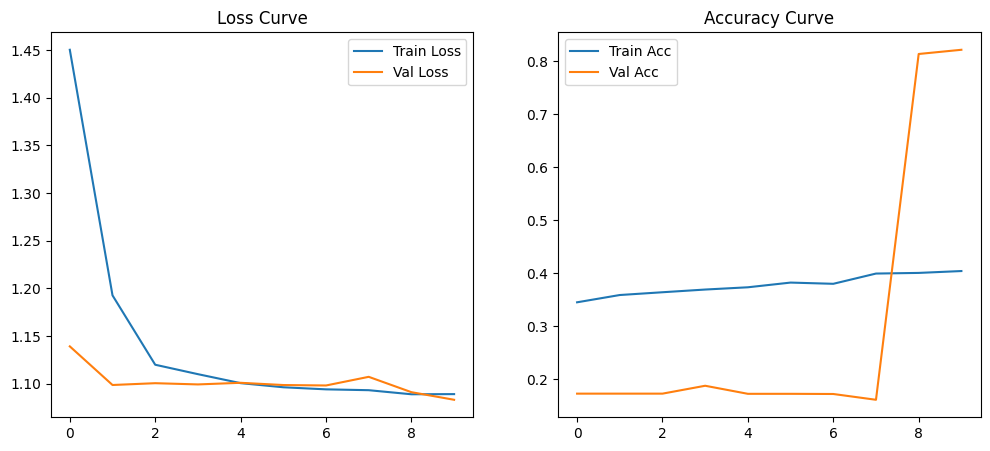

In [101]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy Curve')

plt.show()


In [102]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

114/114 ━━━━━━━━━━━━━━━━━━━━ 57s 501ms/step - accuracy: 0.6941 - loss: 1.0867
Test Accuracy: 0.6941
Test Loss: 1.0867


In [103]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))


              precision    recall  f1-score   support

      normal       0.18      0.71      0.29       748
   pneumonia       0.54      0.88      0.67       390
tubercluosis       0.53      0.01      0.02      2494

    accuracy                           0.25      3632
   macro avg       0.42      0.53      0.32      3632
weighted avg       0.46      0.25      0.14      3632



114/114 ━━━━━━━━━━━━━━━━━━━━ 38s 317ms/step


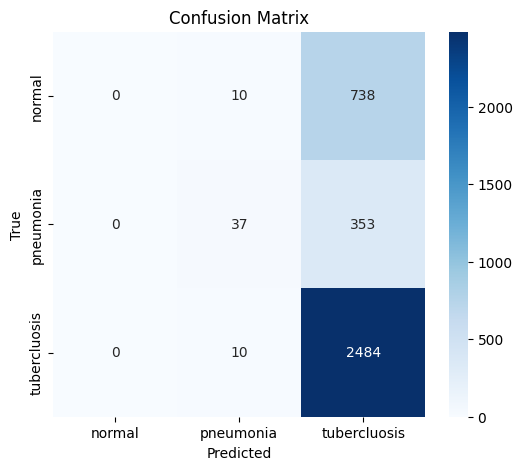

In [104]:
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
